# 04 Additional Models

Decision Tree, Random Forest regressors

## Set Up

In [1]:
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

pd.set_option('display.max_columns', 100)

DATA = '../../data/cleaned_CRMLSSold202512_202605.csv'

#new implement: saving model comparisons and notes
RESULTS = '../../results/model_results.csv'

TARGET = 'ClosePrice'
DATE = 'CloseDate'
TEST_MONTH = '2026-05'
TRAIN_MONTHS = 5
RANDOM_STATE = 42 #needed for decision tree and random forest

## Load

In [2]:
df = pd.read_csv(DATA, parse_dates=[DATE])

#checks
assert len(df) == 61_604, f"Expected 61,604 rows from recent 02_preprocessing.ipynb cleaned .csv. Recieved: {len(df):,}"
assert df[TARGET].notna().all() and (df[TARGET] > 0).all()
assert not any('ListPrice' in c or 'OriginalList' in c for c in df.columns), "List-price leakage"

print(f"{len(df):,} rows x {df.shape[1]} columns | {df[DATE].min().date()} -> {df[DATE].max().date()}")

61,604 rows x 77 columns | 2025-12-01 -> 2026-05-31


## Split
reused from 03_baseline_model


In [3]:
#split data into train/test sets

def chrono_split(data, test_month=TEST_MONTH, window=TRAIN_MONTHS, date=DATE):

      months = data[date].dt.to_period("M")
      test_p = pd.Period(test_month, freq="M")
      train_start = test_p - window 

      test = data[months == test_p]
      train = data[(months >= train_start) & (months < test_p)]
      # Error checks
      assert len(train) > 0 and len(test) > 0, "ERROR: Empty split (check params)"
      assert train[date].max() < test[date].min(), "Chronology violated"
      return train, test


train_df, test_df = chrono_split(df)

print(f"Train: {train_df.shape[0]:,} rows "f"({train_df[DATE].min().date()} --> {train_df[DATE].max().date()})")
print(f"Test:  {test_df.shape[0]:,} rows "f"({test_df[DATE].min().date()} --> {test_df[DATE].max().date()})")

Train: 49,597 rows (2025-12-01 --> 2026-04-30)
Test:  12,007 rows (2026-05-01 --> 2026-05-31)


## Feature Selection

Reused from 03_baseline_model

In [4]:
EXCLUDE = [
    "ListingKey",              
    "CloseDate", "CloseMonth",  

    "ClosePrice",               # target var
    "ClosePrice_log",           # target in log form
    "ClosePrice_repaired",      # metadata

    "CountyOrParish",           # one-hots from 02_preprocessing cleaned csv
    "PostalCode",               

    "LivingArea",               # using LivingArea_log
    "LotSizeAcres",             # using LotSizeAcres_log

    "County_Los_Angeles",       # reference

]

feature = [c for c in df.columns if c not in EXCLUDE]
print(f"{len(feature)} features")

# Checks
assert not any("ClosePrice" in c for c in feature), ("Target column leaked")
assert df[feature].isna().sum().sum() == 0, ("Feature matrix contains NaNs")
assert len(feature) == 66, "Feature set diverged from 03_baseline_model.ipynb result"

X_train, X_test = train_df[feature], test_df[feature]
y_train, y_test = train_df[TARGET], test_df[TARGET]

66 features


## Results Formatting

One row per named experiment (model, version). Re-running an experiment replaces its row, so Restart & Run All stays and the log reflects the latest run.

In [5]:
def log_result(model_name, version, train_r2, test_r2, change_note,
               target_space="log(ClosePrice)"):
    os.makedirs(os.path.dirname(RESULTS), exist_ok=True)
    row = pd.DataFrame([{
        "week": 5, "model": model_name, "version": version,
        "target": target_space, "train_months": TRAIN_MONTHS,
        "test_month": TEST_MONTH, "n_features": len(feature),
        "train_r2": round(train_r2, 4), "test_r2": round(test_r2, 4),
        "change_note": change_note,
    }])
    if os.path.exists(RESULTS):
        log = pd.read_csv(RESULTS)
        log = log[~((log["model"] == model_name) & (log["version"] == version))]   # replace same experiment
        log = pd.concat([log, row], ignore_index=True)
    else:
        log = row
    log.to_csv(RESULTS, index=False)
    print(f"logged: {model_name} {version} | train R2 {train_r2:.4f} | test R2 {test_r2:.4f}")

## Fit/Evaluate Helper

All models evaluated in dollar space. `use_log=True` fits on log(ClosePrice) and back-transforms predictions via `np.exp` before scoring, mirroring 03.

In [6]:
def fit_eval(model, use_log=True, X_tr=None, X_te=None):
    X_tr = X_train if X_tr is None else X_tr
    X_te = X_test if X_te is None else X_te

    ytr = np.log(y_train) if use_log else y_train
    model.fit(X_tr, ytr)

    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)
    if use_log:
        pred_train, pred_test = np.exp(pred_train), np.exp(pred_test)

    return {
        "model": model,
        "pred_train": pred_train,
        "pred_test": pred_test,
        "train_r2": r2_score(y_train, pred_train),
        "test_r2": r2_score(y_test, pred_test),
    }

In [7]:
def plot_pred_actual(ax, y_true, y_pred, title, r2=None):
    ax.scatter(y_true, y_pred, s=6, alpha=0.15, edgecolors="none")
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, ls="--", color="crimson", lw=1, label="perfect (y=x)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.set_xlabel("actual ClosePrice ($)")
    ax.set_ylabel("predicted ClosePrice ($)")
    t = title if r2 is None else f"{title}\ntest R^2 = {r2:.4f}"
    ax.set_title(t)
    ax.legend(loc="upper left", fontsize=8)

## Linear Reference Refit

- Reprod R^2 (0.5071) from 03_baseline_model.ipynb

In [8]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lin = fit_eval(LinearRegression(), use_log=True, X_tr=X_train_s, X_te=X_test_s)
print(f"linear (log): train R^2 = {lin['train_r2']:.4f} | test R^2 = {lin['test_r2']:.4f}")

assert abs(lin['test_r2'] - 0.5071) < 0.0005, "Baseline failed to reproduce 03's result"
BASELINE_R2 = lin['test_r2']

log_result("LinearRegression", "baseline", lin['train_r2'], lin['test_r2'],
           "Week 4 baseline refit as reference")

linear (log): train R^2 = 0.5425 | test R^2 = 0.5071
logged: LinearRegression baseline | train R2 0.5425 | test R2 0.5071


## Decision Tree (DT)

### DT.A
- default parameters (unconstrained), both targets. 

In [9]:
dt_log = fit_eval(DecisionTreeRegressor(random_state=RANDOM_STATE), use_log=True)
dt_raw = fit_eval(DecisionTreeRegressor(random_state=RANDOM_STATE), use_log=False)

print(f"DecisionTree A (log): train R^2 = {dt_log['train_r2']:.4f} | test R^2 = {dt_log['test_r2']:.4f} | gap R^2 = {dt_log['train_r2'] - dt_log['test_r2']:.4f}")
print(f"DecisionTree A (raw): train R^2 = {dt_raw['train_r2']:.4f} | test R^2 = {dt_raw['test_r2']:.4f} | gap R^2 = {dt_raw['train_r2'] - dt_raw['test_r2']:.4f}")
print(f"baseline value to beat: {BASELINE_R2:.4f}")

log_result("DecisionTree", "A-log", dt_log['train_r2'], dt_log['test_r2'],"unconstrained defaults, log target")
log_result("DecisionTree", "A-raw", dt_raw['train_r2'], dt_raw['test_r2'], "unconstrained defaults, raw target", target_space="raw ClosePrice")

DecisionTree A (log): train R^2 = 0.9986 | test R^2 = 0.1370 | gap R^2 = 0.8616
DecisionTree A (raw): train R^2 = 0.9989 | test R^2 = 0.1347 | gap R^2 = 0.8642
baseline value to beat: 0.5071
logged: DecisionTree A-log | train R2 0.9986 | test R2 0.1370
logged: DecisionTree A-raw | train R2 0.9989 | test R2 0.1347


### DT.A Interpretation

***Strengths***
- DT (in general) doesn't rely on scaling
    - generally simpler pipeline
- generally efficient and arguably easier to interpret

***Weaknesses***
- Training Value R^2 = 0.999 (near = 1)
- against baseline:
    - really large gap between yielded R^2 from baseline (0.86)
        - overfit (needs to be fixed)
    - smaller testing R^2 value
        - gap of 0.37
        - we want to surpass the baseline testing R^2 value
- as identified in the baseline, the training set of months is much cheaper which go on to dictate the caps of the leaf nodes in the tree

### DT.B
- attempt to control the overfitting from DT.A

In [10]:
depths = [4, 6, 8, 10, 12, 16, 20]
dt_sweep = []

for d in depths:
    res = fit_eval(DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE), use_log=True)
    dt_sweep.append({"max_depth": d,
                     "train_r2": res["train_r2"],
                     "test_r2": res["test_r2"],
                     "gap": res["train_r2"] - res["test_r2"]})

dt_sweep = pd.DataFrame(dt_sweep)
print(dt_sweep.to_string(index=False))
print(f"\nbaseline value to beat: {BASELINE_R2:.4f}")

best = dt_sweep.loc[dt_sweep["test_r2"].idxmax()]
print(f"best: max_depth={int(best['max_depth'])} | test R^2 {best['test_r2']:.4f}")

 max_depth  train_r2  test_r2       gap
         4  0.463027 0.468573 -0.005546
         6  0.520183 0.497587  0.022596
         8  0.607642 0.380602  0.227040
        10  0.665159 0.382233  0.282926
        12  0.732634 0.382350  0.350283
        16  0.833003 0.297712  0.535291
        20  0.885667 0.285064  0.600603

baseline value to beat: 0.5071
best: max_depth=6 | test R^2 0.4976


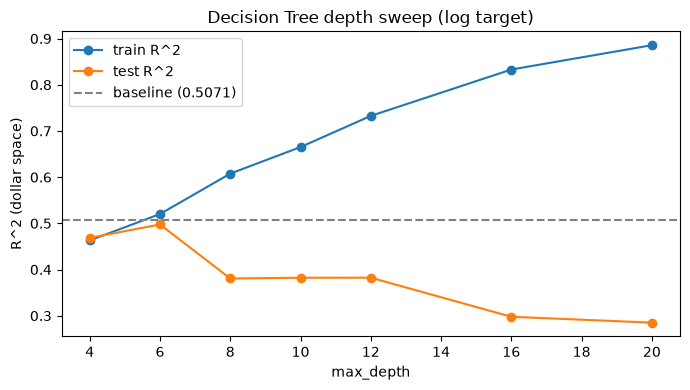

In [11]:
#plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dt_sweep["max_depth"], dt_sweep["train_r2"], marker="o", label="train R^2")
ax.plot(dt_sweep["max_depth"], dt_sweep["test_r2"], marker="o", label="test R^2")
ax.axhline(BASELINE_R2, ls="--", color="gray", label=f"baseline ({BASELINE_R2:.4f})")
ax.set_xlabel("max_depth")
ax.set_ylabel("R^2 (dollar space)")
ax.set_title("Decision Tree depth sweep (log target)")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# refit at best depth and log it
BEST_DT_DEPTH = int(best["max_depth"])
dt_b = fit_eval(DecisionTreeRegressor(max_depth=BEST_DT_DEPTH, random_state=RANDOM_STATE), use_log=True)

print(f"DecisionTree B (log, max_depth={BEST_DT_DEPTH}):\n"
      f"train R^2 = {dt_b['train_r2']:.4f} | test R^2 ={dt_b['test_r2']:.4f} | gap R^2 = {dt_b['train_r2'] - dt_b['test_r2']:.4f}")

log_result("DecisionTree", "B-depth", dt_b["train_r2"], dt_b["test_r2"],
           f"max_depth={BEST_DT_DEPTH} chosen from sweep {depths}, log target")

DecisionTree B (log, max_depth=6):
train R^2 = 0.5202 | test R^2 =0.4976 | gap R^2 = 0.0226
logged: DecisionTree B-depth | train R2 0.5202 | test R2 0.4976


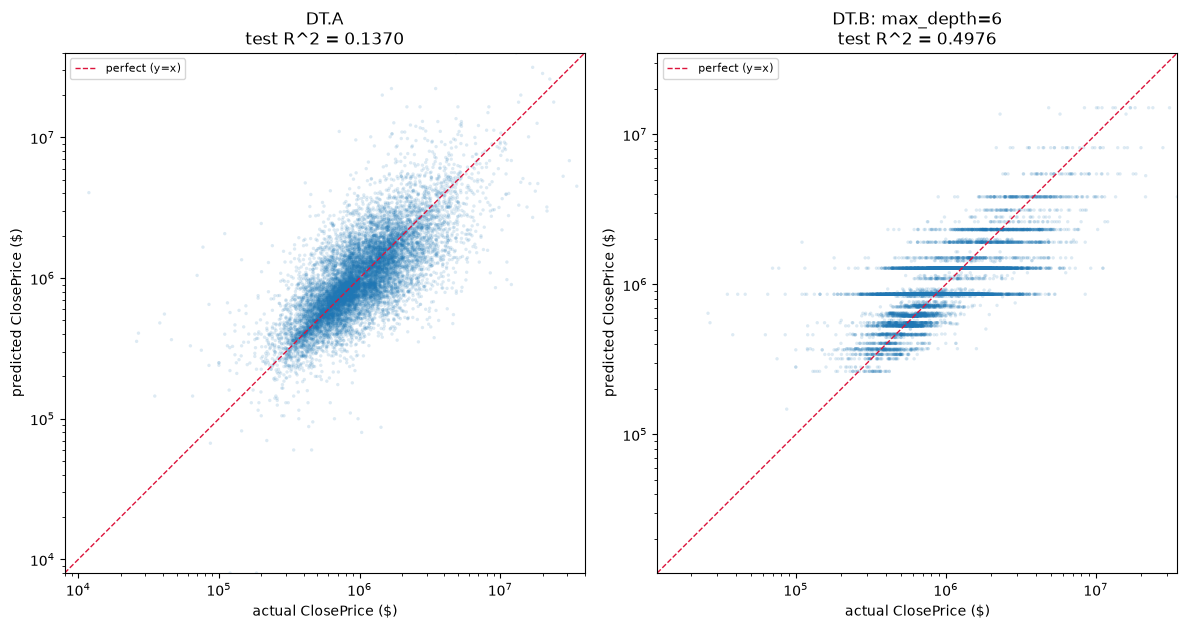

In [13]:
# DT.A vs DT.B (max_depth=6) on test set
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_pred_actual(axes[0], y_test, dt_log["pred_test"],
                 "DT.A", r2=dt_log["test_r2"])
plot_pred_actual(axes[1], y_test, dt_b["pred_test"],
                 f"DT.B: max_depth={BEST_DT_DEPTH}", r2=dt_b["test_r2"])
plt.tight_layout()
plt.show()

### DT.B Interpretation

Graph comparison DTA vs DTB:
- DT.B has stripes due to the distinct values.
    - less variation int he values due to the depth of 6.
- both underpredict at the higher end (expensive homes, right side)

***Strengths***
- the depth fixed the overfitting
    - gap 0.0226 vs DT.A's 0.86
- test R^2 nearly recovered to baseline level (0.4976 vs 0.5071)
    - a tuned single tree is at least competitive, unlike DT.A
- sweep gives a clean picture of the bias-variance tradeoff
    - one interpretable knob (max_depth) controls the whole regime

***Weaknesses***
- still below baseline
    - gap of 0.0095 tuning alone doesn't beat linear
- test R^2 degrades monotonically past depth 6
    - depths 8-12 plateau ~0.38, depths 16-20 fall to ~0.29
    - extra depth memorizes training months rather than learning structure
- piecewise-constant predictions
    - depth 6 = coarse price buckets
    - can't approximate the smooth log-linear relationships
- depth chosen by peeking at test R^2
    - 0.4976 is mildly optimistic; proper selection would use a validation split from training months

Notes:
- depth 4 negative gap (test 0.4686 > train 0.4630)
    - underfit regime, both sets fit poorly
    - test month happens to score slightly higher
        - noise, not bug

In [23]:
### Checking other variations of DT
# exploring a different regularizer

dt_leaf = fit_eval(DecisionTreeRegressor(min_samples_leaf=5, random_state=RANDOM_STATE), use_log=True)

print(f"DecisionTree (min_samples_leaf=5): "
      f"train R^2 = {dt_leaf['train_r2']:.4f} | test R^2 = {dt_leaf['test_r2']:.4f} | gap R^2 = {dt_leaf['train_r2'] - dt_leaf['test_r2']:.4f}")
print(f"DT.B reference (max_depth=6): train {dt_b['train_r2']:.4f} | test {dt_b['test_r2']:.4f}")
print(f"baseline value to beat: {BASELINE_R2:.4f}")
print(f"beats baseline: {dt_leaf['test_r2'] > BASELINE_R2}")

DecisionTree (min_samples_leaf=5): train R^2 = 0.7596 | test R^2 = 0.4789 | gap R^2 = 0.2808
DT.B reference (max_depth=6): train 0.5202 | test 0.4976
baseline value to beat: 0.5071
beats baseline: False


- min_samples_leaf=5: test 0.4789, gap 0.28, still below baseline
    - lands under DT.B (depth6, 0.4976)
        - depth model was the slightly better single-tree regularizer here
    - alludes to the fact that a single tree knob isn't strong enough to beat the linear regression
        - the choice of regularizer doesn't change the conclusion

## Random Forest (RF)

### RF.A
- unconstrained version

In [14]:
rf_a = fit_eval(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    use_log=True
)

print(f"RandomForest A (log): train {rf_a['train_r2']:.4f} | test R^2 {rf_a['test_r2']:.4f} | gap R^2 {rf_a['train_r2'] - rf_a['test_r2']:.4f}")
print(f"baseline value to beat: {BASELINE_R2:.4f}")

log_result("RandomForest", "A-default", rf_a['train_r2'], rf_a['test_r2'], "unconstrained defaults = 100 trees, log target")

RandomForest A (log): train 0.9039 | test R^2 0.5939 | gap R^2 0.3100
baseline value to beat: 0.5071
logged: RandomForest A-default | train R2 0.9039 | test R2 0.5939


### RF.A Interpretations

***Strengths***
- beats baseline: test R^2 0.5939 vs 0.5071 (+0.087)
    - first model this week to clear the linear baseline
- huge jump over the single tree
    - DT.A test 0.137 --> RF.A test 0.594 with the same unconstrained setup
    - averaging 100 trees cancels the variance that made one tree useless
- no scaling needed
    - handles the raw feature matrix directly

***Weaknesses***
- large train/test gap (0.31): train 0.9039 | test 0.5939
    - individual trees still fully memorize
        - the ensemble masks it in test R^2
    - train 0.90 / test 0.59 will read as an overfit but is just something inherent to how RF works
- 40% of variance still unexplained
    - forest captures interactions linear misses
    - could be readjusted through Week 6 feature engineering + Week 7 gradient boosting

### RF.B

- light constraint: each leaf must average at least >= 5 sales
    - attempt to smooth out the single leaf regularization

In [15]:
rf_b = fit_eval(
    RandomForestRegressor(n_estimators=100, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1), use_log=True)

print(f"RandomForest B (log, min_samples_leaf=5):\n"
      f"train R^2 = {rf_b['train_r2']:.4f} | test R^2 = {rf_b['test_r2']:.4f} | gap R^2 = {rf_b['train_r2'] - rf_b['test_r2']:.4f}")
print(f"baseline value to beat: {BASELINE_R2:.4f}")
print(f"RF.A reference: train {rf_a['train_r2']:.4f} | test {rf_a['test_r2']:.4f} | gap {rf_a['train_r2'] - rf_a['test_r2']:.4f}")

log_result("RandomForest", "B-leaf5", rf_b['train_r2'], rf_b['test_r2'], "100 trees, min_samples_leaf=5, log target")

RandomForest B (log, min_samples_leaf=5):
train R^2 = 0.7166 | test R^2 = 0.6043 | gap R^2 = 0.1123
baseline value to beat: 0.5071
RF.A reference: train 0.9039 | test 0.5939 | gap 0.3100
logged: RandomForest B-leaf5 | train R2 0.7166 | test R2 0.6043


In [16]:
# checking if constraint is useful
rf_depths = [8, 12, 16, 20, None]
rf_sweep = []

for d in rf_depths:
    res = fit_eval(
        RandomForestRegressor(max_depth=d, n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), use_log=True)
    rf_sweep.append({"max_depth": d if d is not None else "None",
                     "train_r2": res["train_r2"],
                     "test_r2": res["test_r2"],
                     "gap": res["train_r2"] - res["test_r2"]})

rf_sweep = pd.DataFrame(rf_sweep)
print(rf_sweep.to_string(index=False))
print(f"\nbaseline value to beat: {BASELINE_R2:.4f}")

best_rf = rf_sweep.loc[rf_sweep["test_r2"].idxmax()]
print(f"best depth: max_depth={best_rf['max_depth']} | test R^2 {best_rf['test_r2']:.4f}  (== RF.A, so not logged)")

max_depth  train_r2  test_r2      gap
        8  0.611625 0.548243 0.063383
       12  0.722994 0.576946 0.146049
       16  0.792650 0.587317 0.205333
       20  0.836357 0.592209 0.244148
     None  0.903926 0.593907 0.310019

baseline value to beat: 0.5071
best depth: max_depth=None | test R^2 0.5939  (== RF.A, so not logged)


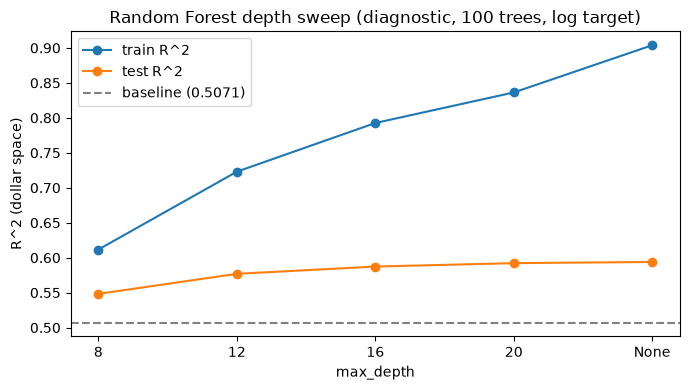

In [17]:
# plot
# None = categorical value
fig, ax = plt.subplots(figsize=(7, 4))
x_labels = rf_sweep["max_depth"].astype(str)
ax.plot(x_labels, rf_sweep["train_r2"], marker="o", label="train R^2")
ax.plot(x_labels, rf_sweep["test_r2"], marker="o", label="test R^2")
ax.axhline(BASELINE_R2, ls="--", color="gray", label=f"baseline ({BASELINE_R2:.4f})")
ax.set_xlabel("max_depth")
ax.set_ylabel("R^2 (dollar space)")
ax.set_title("Random Forest depth sweep (diagnostic, 100 trees, log target)")
ax.legend()
plt.tight_layout()
plt.show()

***Depth-sweep diagnostic (unlogged since rep RF.A)***
- RF test R^2 climbs then flattens with depth, never collapses (0.548 → 0.594, depth 8 → None)
    - contrast with the single tree, peaks at depth 6 then falls to ~0.29
    - averaging 100 deep trees cancels the variance that overfits one tree (bagging)
- best depth = None 
    - reproduces RF.A

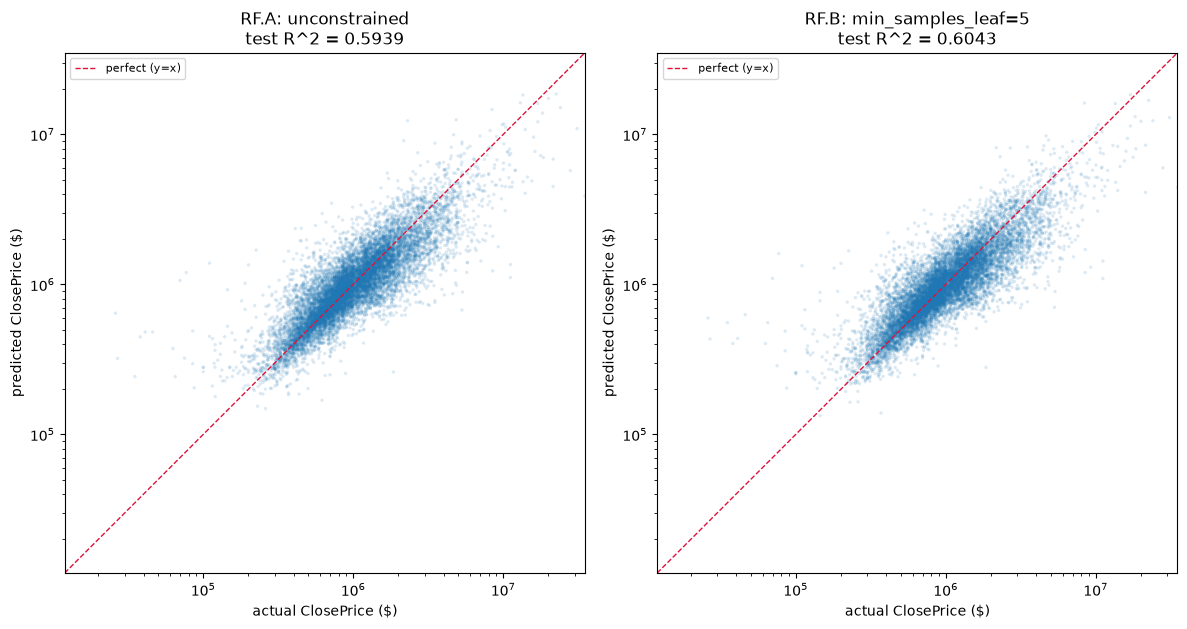

In [18]:
# RF.A vs RF.B (min_samples_leaf=5) on test set
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
plot_pred_actual(axes[0], y_test, rf_a["pred_test"],
                 "RF.A: unconstrained", r2=rf_a["test_r2"])
plot_pred_actual(axes[1], y_test, rf_b["pred_test"],
                 "RF.B: min_samples_leaf=5", r2=rf_b["test_r2"])
plt.tight_layout()
plt.show()

### RF.B Interpret:

***graph***
- test R^2 climbs then flattens: 0.548 --> 0.577 --> 0.587 --> 0.593 --> 0.594 (depth 8 --> None)
    - monotonic, never falls 
- train R^2 keeps rising the whole way (0.61 --> 0.90)
    - gap widens with depth, but test holds 
        - the whole thing absorbs the extra memorization
- every point on the curve sits above baseline
    - even a shallow forest (depth 8) seems to beat linear

***Strengths***
- test R^2 = 0.6043 (beats RF.A = 0.5939 by +0.010)
    - and clears baseline by + 0.097
- gap slashed from 0.31 --> 0.11 (RF.A 0.9039/0.5939 --> RF.B 0.7166/0.6043)
    - forcing >= 5 sales per leaf stops single sale memorization
- regularization improved test and shrank the gap between versions
    - constraint removed noise
- scatter shows a tighter cloud than RF.A
    - less vertical spread = more consistent predictions for similar homes

***Weaknesses***
- gap reduced but not closed (0.11)
    - trees still memorize within the 5-sale floor
- one hand-picked constraint, not a searched optimum
    - min_samples_leaf=5 was just selected but can be tuned later (Week 7?)
    - a sweep might find an even better leaf size
- underpredicts the high end properties (right side outliers)
    - regularization doesn't fix the extrapolation limit 
    - trees just can't predict past training prices

***Notes***
- distinct experiment from RF.A (unlike the depth sweep, which collapsed into it)
    - this is why RF.B = leaf5 replaced RF.B = depth-sweep in the log

***RF vs DT comparison***
- DT sweep peaks at depth 6 then collapses (test fell to ~0.29 by depth 20)
- RF depth sweep stays high without collapse
    - deep trees that individually overfit generalize when averaged, so the ensemble doesn't overfit the way one tree does
- Test R^2:
    - DT.A = 0.137 | RF.A = 0.594
        - gap of 0.457
        - both unconstrained bases
    - DT.B = 0.498 (max_depth=6) | RF.B = 0.604 (min_samples_leaf=5)
        - both the regularized variant of each family
        - regularizing the tree barely helped (still < baseline)
            - made it the best model
- the forest tunes better and changes the failure mode
    - single tree: forced to choose between noisy (deep) or coarse (shallow)
    - forest: keeps depth *and* stays stable

## Compare to Baseline

In [19]:
results = pd.read_csv(RESULTS)
results["delta_vs_baseline"] = (results["test_r2"] - BASELINE_R2).round(4)
results["beats_baseline"] = results["delta_vs_baseline"] > 0
results = results.sort_values("test_r2", ascending=False).reset_index(drop=True)

print(results[["model", "version", "train_r2", "test_r2",
               "delta_vs_baseline", "beats_baseline"]].to_string(index=False))

           model   version  train_r2  test_r2  delta_vs_baseline  beats_baseline
    RandomForest   B-leaf5    0.7166   0.6043             0.0972            True
    RandomForest A-default    0.9039   0.5939             0.0868            True
LinearRegression  baseline    0.5425   0.5071            -0.0000           False
    DecisionTree   B-depth    0.5202   0.4976            -0.0095           False
    DecisionTree     A-log    0.9986   0.1370            -0.3701           False
    DecisionTree     A-raw    0.9989   0.1347            -0.3724           False


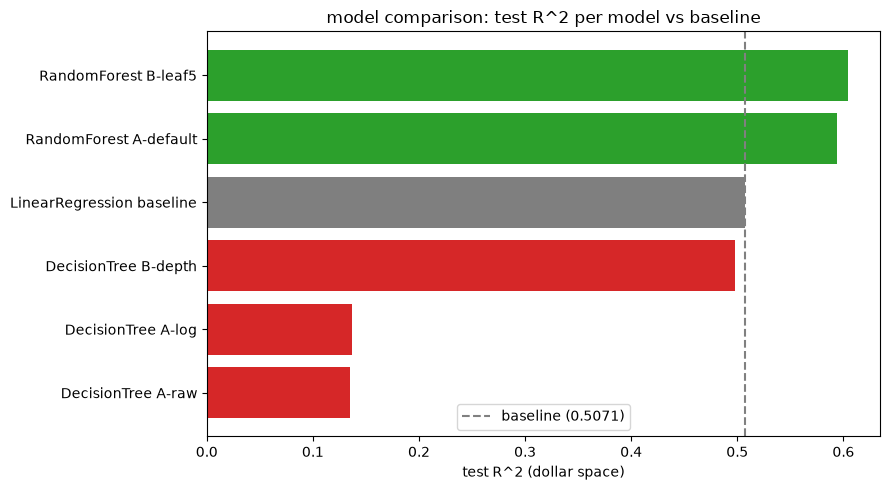

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
labels = results["model"] + " " + results["version"]
colors = ["tab:gray" if m == "LinearRegression" else ("tab:green" if b else "tab:red") for m, b in zip(results["model"], results["beats_baseline"])]
ax.barh(labels, results["test_r2"], color=colors)
ax.axvline(BASELINE_R2, ls="--", color="gray", label=f"baseline ({BASELINE_R2:.4f})")
ax.invert_yaxis()
ax.set_xlabel("test R^2 (dollar space)")
ax.set_title("model comparison: test R^2 per model vs baseline")
ax.legend()
plt.tight_layout()
plt.show()

## Results


In [22]:
# Display the experiment log, ranked by test R²
results_log = pd.read_csv(RESULTS)
results_log = results_log.sort_values("test_r2", ascending=False).reset_index(drop=True)
display(results_log[["model", "version", "target", "train_r2", "test_r2", "change_note"]])

,model,version,target,train_r2,test_r2,change_note
0,RandomForest,B-leaf5,log(ClosePrice),0.7166,0.6043,"100 trees, min_samples_leaf=5, log target"
1,RandomForest,A-default,log(ClosePrice),0.9039,0.5939,"unconstrained defaults = 100 trees, log target"
2,LinearRegression,baseline,log(ClosePrice),0.5425,0.5071,Week 4 baseline refit as reference
3,DecisionTree,B-depth,log(ClosePrice),0.5202,0.4976,"max_depth=6 chosen from sweep [4, 6, 8, 10, 12..."
4,DecisionTree,A-log,log(ClosePrice),0.9986,0.1370,"unconstrained defaults, log target"
5,DecisionTree,A-raw,raw ClosePrice,0.9989,0.1347,"unconstrained defaults, raw target"


Every Random Forest configuration beat the Week 4 linear baseline (log target, test R^2 = 0.5071)

The best model of the experiemnt: 
    - RandomForest Method B: test R^2 = 0.6043
    - wins over baseline by +0.097

The leaf constraint improved on the unconstrained forest (RF.A 0.5939) while cutting the train/test gap from 0.31 to 0.11
    - less overfitting
    - better generalization.

Ranking by test R^2: RF.B (0.604) > RF.A (0.594) > baseline (0.507) > DT.B (0.498) > DT.A (0.137)

### Summary of Approach

All models share one evaluation contract so results are comparable:

- **Target:** log(ClosePrice)
    - fit in log space
    - predictions back-transformed via `np.exp` before scoring
    - handles the right-skewed price dist
- **Metric:** R^2 in dollar space (not log space)
    - every model judged on the same scale as the baseline.
- **Split:** fixed chronological split 
    - train Dec 2025 to Apr 2026
    - test May 2026
    - No shuffling
    - real mirror forecasting / future prediction
- **Features:** same 66-feature matrix as the Week 4 baseline
    - `County_Los_Angeles` as the reference category so dropped
- **Reproducibility:** `random_state=42` on every tree/forest 
    - Restart & Run All every run
- **Logging:** one row per named experiment in `model_results.csv`
    - hyperparameter sweeps stay in the notebook, only the chosen config is logged in new csv

**Decision Tree**
- no scaling required
- DT.A
    - unconstrained defaults (baseline behavior)
- DT.B 
    - sweeps `max_depth` to control overfitting
- attempted to try a different regularization with min_samples_leaf but got an even weaker result than DT.A/DT.B (unlogged)

**Random Forest** 
- 100 trees (`n_jobs=-1`)
- RF.A 
    - unconstrained defaults
- RF.B 
    - applies constraint `min_samples_leaf=5` 
        - narrows the test/train gapping
- Depth sweep shows that the best depth = None, which just reproduces RF.A
    - confirming the forest doesn't need depth-capping in the first place
- Bagging method of many trees is the mechanism expected to fix the single-tree variance problem